# mGPLVM analysis on recurrent units

In [ ]:
%load_ext autoreload
%autoreload 2
import os
import pickle
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from sklearn.linear_model import RidgeCV

import mgplvm as mgp
import utils as utils
from utils.path_settings import *


plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False
# device = mgp.utils.get_device()
device = torch.device('cuda')
torch.set_default_device(device)
torch.set_default_dtype(torch.float64)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
goal = 1
model_type = 4
model_name = f"LAL_weight_decay_single_layer_ReLU_32_type{model_type}"
# model_name = "LAL_weight_decay"
neural_activations = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/network_activity_{model_name}.pt")
cx = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/positions_{model_name}.pt")
if goal: 
    positions = torch.tensor(cx[:, [0, 2]].reshape(-1, neural_activations.shape[-2], 2))
else:
    positions = torch.tensor(cx[:, :2].reshape(-1, neural_activations.shape[-2], 2))
scaling = 1
positions[..., 1] = ((positions[..., 1] + np.pi) % (2 * np.pi) * scaling) + (1- scaling) * np.pi - np.pi
neural_activations = neural_activations.reshape(-1, neural_activations.shape[-1])
positions = positions.reshape(-1, positions.shape[-1])


In [28]:
# import everything
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import Operator.Operator as o
import copy
from Network_models.CTrainer_Pred_CAN import CTrainer_Pred_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator
from Operator.miscellaneous import *
from Network_models.GRUController import GRUControllerAlltogether
from SimulateDatasets.ContrastiveGenerator import ControlGenerator_GRU
from Network_models.CTrainer_GRU import CTrainer_GRU

# set up rep net
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 1,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        # "nonlinearity" : "tanh",
        "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)

data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=-1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta

d = data_gen.generate_data(10, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()

rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1]) if dim != 1 else nn.Linear(128, dpositions.shape[1]*2),
)

mapnet = torch.load(path.replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(path.replace("model.pth", "readoutnet.pth"))


from Operator.Operator import *
from Operator.miscellaneous import *

delay = 1
plant_state_size = 32
dt_plant = 0.1
action_modality = "velocity"
feedback_noise = 0.5
output_size = 32 if model_type != 4 else 128
action_size = 1 # from plant to operator
hidden_control_dim = 128
recurrent_control_dim = hidden_control_dim if hidden_control_dim > 0 else output_size
recurrent_control = False

modularized = True

try: 
    if output_size == 32:
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly32.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal32.pth")
    else: 
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly128.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal128.pth")
    fly.delay = delay
    fly.feedback_noise = feedback_noise
except:
    print ("No model to load")

    fly = Fly(
        {
            "device": "cuda", 
            "delay": delay,
            "plant_state_size": plant_state_size,
            "dt": dt_plant,
            "action_modality": action_modality,
            "feedback_noise": feedback_noise,
            "width": 0.1, # this is the widht o the 
        }
    )
    plant = LAL(controller_dim = output_size, n_lal_neurons=plant_state_size, use_dale = True, excitation_ratio = 0.8, init_scale = 0.7, dt = dt_plant)


if modularized:
    im1 = InternalModelMLP({
        "efference1": output_size, 
        "efference2": plant_state_size,
        "sensory": fly.state_size, 
        "can": rnn.rnn.rep_units 
    }, 
    [128], 
    action_size, 
    0, "relu", "linear", zero_initialization=False).cuda()

    use_rep, use_feedback = True, True
else:
    use_rep = False
    use_feedback = False
    im1_input_size = output_size + fly.state_size * use_feedback + rnn.rnn.rep_units * use_rep
    im1 = MLP(im1_input_size, 128, action_size, 0, "relu", "linear", zero_initialization=False).cuda()
# predictor = SingleLayerLM(rnn.rnn.hidden_size, wheel.position_size, 8).cuda()
predictor = MLP(rnn.rnn.hidden_size, 128, fly.position_size, 8, "relu", "tanh", zero_initialization=False, normalize=True).cuda()
fly.readout_matrix.weight.data = torch.cat([torch.ones_like(fly.readout_matrix.weight.data[:, :plant_state_size//2]), -torch.ones_like(fly.readout_matrix.weight.data[:, plant_state_size//2:])], dim=-1)
from copy import deepcopy
def trainer_factory(cond_params):
    # 1) Copy any modules so each trainer is independent
    plant_net = deepcopy(plant)
    operator  = deepcopy(fly)
    IM1_net   = deepcopy(im1)
    # predictor/readout
    predictor_copy = deepcopy(readoutnet)
    readout_net    = readoutnet

    # 2) Build the model_params, merging in cond_params
    hidden_dim = cond_params["hidden_control_dim"]
    model_params = {
        "rep_net": rnn,
        "plant": plant_net,
        "operator": operator,
        "IM1": IM1_net,
        "predictor": predictor_copy,
        "readoutnet": readout_net,
        "output_size":        cond_params["output_size"],
        "rep_units_only":     True,
        "recurrent_control":  cond_params["recurrent_control"],
        "activation":         "ReLU",
        "hidden_control_dim": hidden_dim,
        "recurrent_control_dim": hidden_dim if hidden_dim != 0 else cond_params["output_size"],
        "device":             "cuda",
        "use_rep":            use_rep,
        "use_feedback":       use_feedback,
    }

    model_specs = {
        "model_name":   "PredControlNetCAN_2",
        "model_path":   "Network_models.PIDController",
        "model_params": model_params,
    }

    optimizer_specs = {
        "compartmental_optimization": True,
        "optimizer_name":             "Adam",
        "optimizer_params":           {"lr": 0.003},
    }

    # 3) Put together the trainer config
    trainer_config = {
        "model_specs":              model_specs,
        "optimizer_specs":          optimizer_specs,
        "control_period":           20,
        "random_initial_condition": True,
        "additional_loss":          ["final_distance", "control_norm"],
        "save_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/", 
        "check_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/",
        "log_path":           LOG_PATH + f"/Pred_Controller/Temp/",
        # (you can add save_path/check_path/log_path here if needed)
    }

    # 4) Instantiate and return
    return CTrainer_Pred_CAN(trainer_config)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
input_connected: True
Using custom activation BiologicalReLU
1
no scheduler
Model loaded via train
0.1


In [397]:
positions.reshape(4096, 1, 20, 2)[2047, ..., -1]

tensor([[-3.0805,  2.7608,  2.3398,  1.7105,  0.9253,  0.4600,  0.4198,  0.4198,
          0.4198,  0.3901,  0.3207,  0.2664,  0.2664,  0.2703,  0.2703,  0.2703,
          0.2703,  0.2703,  0.2703,  0.2703]], dtype=torch.float32)

In [398]:
neural_activations.shape

torch.Size([81920, 577])

In [52]:
neural_activations = neural_activations.reshape(4096, 1, 20, neural_activations.shape[-1])[:, :, 0, :]
positions = positions.reshape(4096, 1, 20, positions.shape[-1])[:, :, 0, :]

In [53]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [54]:
path_dicts = {
    1: {
        "it": 0, 
        "control_norm_weight": 0.3
    },
    2: {
        "it": 0,
        "control_norm_weight": 1.5
    },
    3: {
        "it": 2,
        "control_norm_weight": 3.1
    },
    4:{
        "it": 1,
        "control_norm_weight": 0.1
    }

}

conditions = {
    "full": {
        "recurrent_control": True,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_hidden": {
        "recurrent_control": True,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
    "no_hidden_no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
    "no_hidden_no_recurrence_128": {
        "recurrent_control": False,
        "hidden_control_dim": 0,
        "output_size": 128, 
    },
}

it = path_dicts[model_type]["it"]
condition = "no_hidden_no_recurrence" if model_type != 4 else "no_hidden_no_recurrence_128"
action_weight_, loss_traj_weight_, convergence_loss_weight_, control_norm_weight_ = 0.3, 0.3, 0.3, path_dicts[model_type]["control_norm_weight"]

weight_dict = {
    "action_weight": action_weight_,
    "loss_traj_weight": loss_traj_weight_,
    "convergence_loss_weight": convergence_loss_weight_,
    "control_norm_weight": control_norm_weight_
}
action_weight, loss_traj_weight, convergence_loss_weight, control_norm_weight = weight_dict.values()

trainer = trainer_factory(conditions[condition])
output_size = conditions[condition]["output_size"]
hidden_control_dim = conditions[condition]["hidden_control_dim"]
recurrent_control = conditions[condition]["recurrent_control"]
path = MODEL_SAVE_PATH + f"/LAL/modularized_cp_{"single_sheet" if hidden_control_dim == 0 else "hidden" + str(hidden_control_dim)}_{output_size}_{loss_traj_weight}_{action_weight}_{convergence_loss_weight}_{control_norm_weight}_iteration{it}{"no_recurrence" if not recurrent_control else ""}.pth"
trainer.load_checkpoint(path)


Model loaded
no scheduler
['final_distance', 'control_norm']


In [55]:
# W_pos = F.softplus(model_state_dict["plant.W_param"]) * model_state_dict["plant.dale_signs"]
W_pos = trainer.model.plant.apply_dale_constraint(trainer.model.plant.W_param.data).cpu().detach()
controller_signs = torch.sign(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu())[0].cpu().numpy()

In [56]:
controller_signs.shape

(128,)

In [57]:
# Subsample the conditions
m = 2000
# n = [32, 32, 32, 20, 4]
n = [16, 16, 4, 4]
load = False

if model_name is not None: 
    if model_name[:-1] == "LAL_weight_decay_single_layer_ReLU_32_type":
        if model_type != 4:
            partitions = {
                "Controller_output_left": np.where(controller_signs < 0)[0] + 161,
                "Controller_output_right": np.where(controller_signs > 0)[0] + 161, 
                # "Internal Model": (0, 128),
                # "Controller_hidden": (129, 129 + 32),
                # "Controller_output": (161, 193), 
                "Continuous Attractor": np.arange(193, 449),
                "Goal Population": np.arange(449, 577), 
            }
        else:
            partitions = {
                "Controller_output_left": np.where(controller_signs < 0)[0] + 257,
                "Controller_output_right": np.where(controller_signs > 0)[0] + 257, 
                "Continuous Attractor": np.arange(385, 641),
                "Goal Population": np.arange(641, 769), 
            }
    elif model_name == "LAL_weight_decay_single_layer_32":
        partitions = {
            "Internal Model": (0, 129),
            "Controller_hidden": (129, 129 + 32),
            "Controller_output": (161, 193), 
            "Continuous Attractor": (193, 449),
        }
    elif model_name == "LAL_weight_decay_single_layer_128":
        partitions = {
            "Internal Model": (0, 129),
            "Controller_hidden": (129, 129 + 128),
            "Controller_output": (257, 385), 
            "Continuous Attractor": (385, 641),
            "Actuator": (641, 645)
        }
    else:
        partitions = {
            "Internal Model": (0, 129),
            "Controller_hidden": (129, 129 + 128),
            "Controller_output": (257, 289), 
            "Continuous Attractor": (289, 545),
        }
else:
    partitions = {
        "Internal Model": (0, 128),
        "Predictive Model": (128, 258),
        "Controller": (258, 418),
        "Continuous Attractor": (418, 674),
    }
if load: 
    try: 
        indices = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices.pt")
        subsampling_index_1 = indices["index 1"]
        subsampling_index_2 = indices["index 2"]
    except:
        print("No indices found; subsampling randomly")
        subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
else: 
    subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
    if model_name is None:
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
    else:
        subsampling_index_2 = []
        # for i, (partition_name, (start, end)) in enumerate(partitions.items()):
            # partition_indices = torch.arange(start, end)
        for i, (partition_name, partition_indices) in enumerate(partitions.items()):
            if isinstance(partition_indices, np.ndarray):
                partition_indices = torch.Tensor(partition_indices).int().to(device)
            # if i == len(partitions) - 1:
            if True:
                sampled_indices = partition_indices
            # else:
            #     sampled_indices = partition_indices[torch.randperm(len(partition_indices))[:n[i]]]
            subsampling_index_2.append(sampled_indices)
        subsampling_index_2 = torch.cat(subsampling_index_2)

neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1][:, subsampling_index_2].cuda()
positions_subsampled = positions.reshape(-1, positions.shape[-1])[subsampling_index_1].cuda()
print(f"Neural activations subsampled to shape {neural_activations_subsampled.shape}")
print(f"Positions subsampled to shape {positions_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1)#.cpu().detach()


Neural activations subsampled to shape torch.Size([2000, 512])
Positions subsampled to shape torch.Size([2000, 2])


In [42]:
partitions

{'Controller_output_left': array([260, 261, 262, 264, 266, 267, 268, 273, 274, 276, 278, 279, 281,
        283, 287, 290, 292, 293, 295, 296, 297, 298, 300, 302, 303, 306,
        308, 312, 314, 315, 317, 321, 322, 323, 327, 329, 333, 334, 335,
        336, 339, 341, 344, 346, 348, 349, 350, 352, 353, 355, 358, 363,
        365, 368, 369, 371, 373, 374, 375, 377, 380, 382, 383, 384]),
 'Controller_output_right': array([257, 258, 259, 263, 265, 269, 270, 271, 272, 275, 277, 280, 282,
        284, 285, 286, 288, 289, 291, 294, 299, 301, 304, 305, 307, 309,
        310, 311, 313, 316, 318, 319, 320, 324, 325, 326, 328, 330, 331,
        332, 337, 338, 340, 342, 343, 345, 347, 351, 354, 356, 357, 359,
        360, 361, 362, 364, 366, 367, 370, 372, 376, 378, 379, 381]),
 'Continuous Attractor': array([385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397,
        398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
        411, 412, 413, 414, 415, 416, 417, 418, 419, 

In [66]:
import matplotlib.colors as mcolors
torch.set_default_device('cpu')
def plot_controller_connectome(neural_activity, positions, W, partitions, min_avg_activity=0.01, imshow = True):
    """
    Plots left and right controller connectivity matrices as heatmaps, after filtering and reordering neurons
    based on activity and preferred angle tuning.

    Args:
        neural_activity: torch.Tensor (4096, N)
        positions: torch.Tensor (4096, 2) -- [heading, goal]
        W: torch.Tensor (32, 384) -- weight matrix from [Goal, CAN] to Controller
        partitions: dictionary with cell population identity
        min_avg_activity: float, activity threshold to retain neurons
    """

    def compute_preferred_angle(activity, angles):
        sin_sum = (activity * torch.sin(angles[:, None])).sum(dim=0)
        cos_sum = (activity * torch.cos(angles[:, None])).sum(dim=0)
        return (torch.atan2(sin_sum, cos_sum)) % (2 * np.pi)

    # Extract partitions
    goal_idx = partitions["Goal Population"]
    can_idx = partitions["Continuous Attractor"]
    ctrl_left = partitions["Controller_output_left"]
    ctrl_right = partitions["Controller_output_right"]

    # Filter goal neurons
    goal_activity = neural_activity[:, goal_idx]
    goal_valid = goal_activity.mean(0) > min_avg_activity
    goal_activity = goal_activity[:, goal_valid]
    goal_pref = compute_preferred_angle(goal_activity, positions[:, 1])
    goal_order = torch.argsort(goal_pref)
    goal_idx_filtered = torch.tensor(goal_idx)[goal_valid][goal_order]
    goal_pref_filtered = goal_pref[goal_order]

    # Filter CAN neurons
    can_activity = neural_activity[:, can_idx]
    can_valid = can_activity.mean(0) > min_avg_activity
    can_activity = can_activity[:, can_valid]
    can_pref = compute_preferred_angle(can_activity, positions[:, 0])
    can_order = torch.argsort(can_pref)
    can_idx_filtered = torch.tensor(can_idx)[can_valid][can_order]
    can_pref_filtered = can_pref[can_order]

    # Reconstruct reordered weight matrix (inputs)
    can_length = can_idx.shape[0]
    input_order_rebased = ([ goal_idx_filtered - goal_idx[0] + can_length,  can_idx_filtered  - can_idx[0]])
    # input_order_rebased = input_order - can_idx[0]  # assuming W columns = [goal, CAN]
    # print(f"{can_idx[0]}")

    # Filter and sort controller neurons
    # ctrl_idx_all = torch.tensor(ctrl_left.tolist() + ctrl_right.tolist())
    # ctrl_activity = neural_activity[:, ctrl_idx_all] 
    ctrl_idx_all = torch.arange(min(min(ctrl_left), min(ctrl_right)), max(max(ctrl_left), max(ctrl_right)) + 1)
    ctrl_activity = neural_activity[:, ctrl_idx_all]
    print(ctrl_activity.mean(0))
    ctrl_valid = ctrl_activity.mean(0) > min_avg_activity
    ctrl_pref = compute_preferred_angle(ctrl_activity, positions[:, 1])
    ctrl_order = torch.argsort(ctrl_pref)
    # ctrl_idx_filtered = ctrl_idx_all[ctrl_valid][ctrl_order]
    valid_ctrl_ordered = ctrl_order[ctrl_valid[ctrl_order]]
    print(ctrl_valid)
    print(valid_ctrl_ordered)

    W_reordered_goal, W_reordered_can  = (W[:, input_order_rebased[0]], W[:, input_order_rebased[1]])
    W_filtered_goal, W_filtered_can = [W[valid_ctrl_ordered] for W in (W_reordered_goal, W_reordered_can)]
    # W_filtered = W[valid_ctrl_ordered, input_order_rebased]
    ctrl_filtered_idx = ctrl_idx_all[valid_ctrl_ordered]
    ctrl_pref_filtered = ctrl_pref[ctrl_order]
    print(f"Filtered controller neurons: {ctrl_filtered_idx.shape[0]}")

    # Split into left/right
    is_left = torch.tensor([i in ctrl_left for i in ctrl_filtered_idx.tolist()])
    W_left = [W[is_left] for W in (W_filtered_goal, W_filtered_can)]
    W_right = [W[~is_left] for W in (W_filtered_goal, W_filtered_can)]

    # ctrl_filtered_idx = ctrl_idx_all[valid_ctrl_ordered]

    ctrl_filtered_idx_left = ctrl_filtered_idx[is_left]
    ctrl_filtered_idx_right = ctrl_filtered_idx[~is_left]
    ctrl_pref_filtered_left = ctrl_pref_filtered[ctrl_valid][is_left]
    ctrl_pref_filtered_right = ctrl_pref_filtered[ctrl_valid][~is_left]

    # for each W_left and W_right, filter out low weight 
    # W_left = [W[W_left[0].abs().mean(dim=1) + W_left[0].abs().mean(dim=1) > 0.01] for W in W_left]
    # W_right = [W[W_right[0].abs().mean(dim=1) + W_right[0].abs().mean(dim=1) > 0.05] for W in W_right]

    # Plot
    pop = ["Goal", "Current"]
    fig, axes = plt.subplots(2, 2, figsize=(8, 6), gridspec_kw={'width_ratios': [1, 1], 'height_ratios': [1, 1]})
    for i in range(2): 
        W_l, W_r = W_left[i], W_right[i]
        titles = [f"{pop[i]} to Left Controller", f"{pop[i]} to Right Controller"]
        for j, (W_part, title) in enumerate(zip([W_l, W_r], titles)):
            ax = axes[j, i]
            abs_max = torch.abs(W_part).max().item()
            norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

            if imshow: 
                im = ax.imshow(W_part, aspect='auto', cmap='coolwarm', origin = 'lower',norm = norm)
            else: 
                if pop[i] == "Goal": 
                    if j == 0: 
                        x_mesh, y_mesh = np.meshgrid(goal_pref_filtered.detach().cpu(), ctrl_pref_filtered_left.detach().cpu())
                    else:
                        x_mesh, y_mesh = np.meshgrid(goal_pref_filtered.detach().cpu(), ctrl_pref_filtered_right.detach().cpu())
                else:
                    if j == 0: 
                        x_mesh, y_mesh = np.meshgrid(can_pref_filtered.detach().cpu(), ctrl_pref_filtered_left.detach().cpu())
                    else:
                        x_mesh, y_mesh = np.meshgrid(can_pref_filtered.detach().cpu(), ctrl_pref_filtered_right.detach().cpu())
                im = ax.scatter(x_mesh, y_mesh, c=W_part.detach().cpu().numpy(), s=50, cmap='coolwarm', norm=norm, marker='|', alpha =1, linewidth = 2)
                ax.plot([0, 2 * np.pi], [0, 2 * np.pi], color='black', linestyle='--', linewidth=1, label='Identity Line')
                ax.legend(loc='upper right')
            ax.set_title(title)
            if j == 1: 
                ax.set_xlabel(f'Input neurons')
            else:
                ax.set_xticks([])
            if i == 0: 
                if not imshow: 
                    ax.set_yticks([0, np.pi, 2 * np.pi])
                    ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
                else:
                    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

                ax.set_ylabel(f'Controller neurons')
            else:
                ax.set_yticks([])
            plt.colorbar(im, ax=ax, shrink=0.6)
    plt.suptitle(f"Upstream-Controller Connectome, type {model_type}")
    plt.tight_layout()
    # plt.show()


    ctrl_pref_2 = compute_preferred_angle(ctrl_activity, positions[:, 0])
    
    ctrl_pref_full = torch.cat([ctrl_pref_2.unsqueeze(1), ctrl_pref.unsqueeze(1)], dim = -1)
    return goal_idx_filtered, can_idx_filtered, ctrl_filtered_idx_left, ctrl_filtered_idx_right, ctrl_filtered_idx, fig, ctrl_pref_full

tensor([7.7247e-02, 5.5803e-04, 3.1634e-02, 4.3241e-02, 3.1397e-02, 3.2658e-02,
        4.9507e-02, 8.4598e-02, 3.4663e-02, 9.8495e-02, 6.7055e-02, 0.0000e+00,
        1.1191e-01, 1.1517e-01, 8.9014e-02, 1.3938e-01, 4.6005e-02, 0.0000e+00,
        5.2844e-02, 2.9410e-02, 0.0000e+00, 5.0951e-02, 0.0000e+00, 1.6903e-01,
        7.9113e-02, 8.3755e-02, 7.6040e-02, 6.0056e-02, 1.1222e-01, 1.3297e-01,
        8.8702e-02, 1.0098e-01, 4.3483e-02, 2.6243e-02, 0.0000e+00, 9.1972e-02,
        8.9586e-02, 0.0000e+00, 2.7743e-02, 5.0388e-02, 8.7872e-02, 5.3845e-02,
        8.0934e-02, 6.6883e-02, 6.0164e-02, 5.8118e-02, 4.2428e-02, 6.8153e-02,
        1.1389e-01, 6.5887e-02, 3.5105e-02, 7.0448e-02, 5.8812e-02, 6.6662e-02,
        5.7532e-02, 5.1557e-02, 3.9287e-02, 2.9862e-02, 4.7325e-02, 7.0129e-02,
        3.0219e-02, 4.2393e-02, 3.7552e-02, 7.3911e-02, 1.7962e-02, 5.9247e-02,
        8.1761e-02, 7.9490e-02, 9.5915e-02, 1.4542e-01, 0.0000e+00, 1.0507e-01,
        2.6625e-02, 1.2149e-01, 7.0915e-

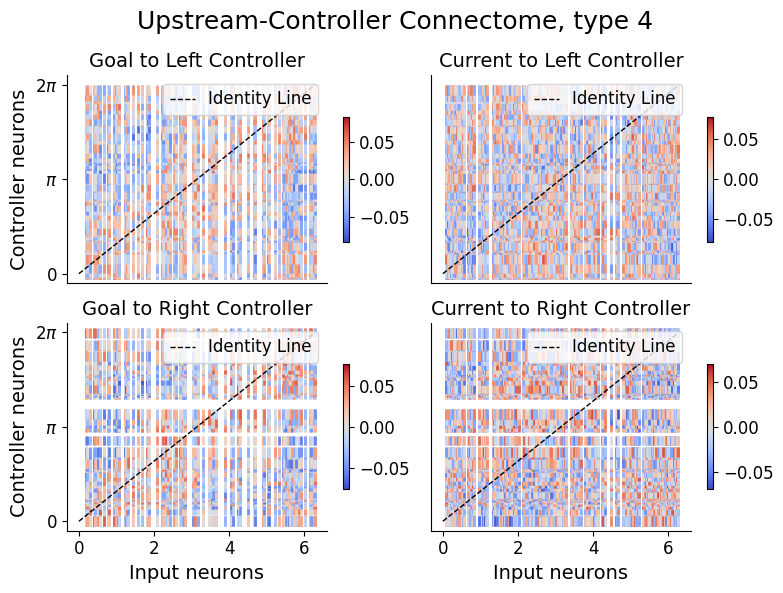

In [68]:
imshow = False
g, c, vl, vr, v, fig, cpf = plot_controller_connectome(neural_activations.squeeze(1).cpu(), positions.squeeze(1).cpu(), trainer.model.W_xh.weight.data.cpu(), partitions, min_avg_activity=0.01, imshow=imshow)
# Save the figure
fig.savefig(f"{FIG_PATH}/LAL_connectorm_type{model_type}{"located" if not imshow else ""}.png", bbox_inches='tight', dpi=300)

In [61]:
torch.save(cpf, f"{MODEL_SAVE_PATH}/LAL_ctrl_pref_type{model_type}")

In [178]:
trials = 4096
q0 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q1 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q0, q1 = torch.meshgrid(q0.squeeze(), q1.squeeze(), indexing='ij')

In [102]:
positions[4000]

tensor([[ 1.6242, -2.2939]], device='cuda:0')

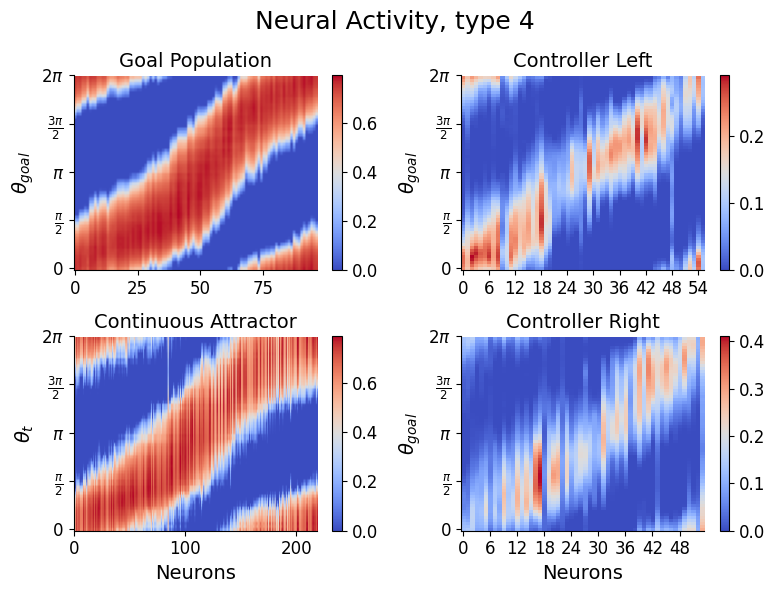

In [69]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0, 0].imshow(neural_activations.reshape(64, 64, -1)[...,  g].mean(dim = 0).cpu().detach().numpy(), aspect='auto', cmap='coolwarm', origin = 'lower')
ax[0, 0].set_title("Goal Population")
ax[1, 0].imshow(neural_activations.reshape(64, 64, -1)[..., c].mean(dim = 1).cpu().detach().numpy(), 
           aspect='auto', cmap='coolwarm', origin = 'lower')
ax[1, 0].set_title("Continuous Attractor")
ax[0, 1].imshow(neural_activations.reshape(64, 64, -1)[..., vl].mean(dim = 0).cpu().detach().numpy(), aspect='auto', cmap='coolwarm', origin = 'lower')
ax[0, 1].set_title("Controller Left")
ax[1, 1].imshow(neural_activations.reshape(64, 64, -1)[..., vr].mean(dim = 0).cpu().detach().numpy(), aspect='auto', cmap='coolwarm', origin = 'lower')
for a in ax.flatten():
    a.set_yticks(np.linspace(0, 64, 5))
    a.set_yticklabels(["0", r"$\frac{\pi}{2}$", r"$\pi$", r"$\frac{3\pi}{2}$", r"$2\pi$"])
    a.set_ylabel(r"$\theta_{goal}$")

ax[1, 0].set_ylabel(r"$\theta_t$")

ax[1, 0].set_xlabel("Neurons")
ax[1, 1].set_xlabel("Neurons")
ax[0, 1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax[1, 1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax[1, 1].set_title("Controller Right")
# ax[1].set_ylabel(fr"$\theta_t$")
# ax[2].set_ylabel(r"$\theta_{goal}$")
for i in range(4):
    plt.colorbar(ax.flatten()[i].images[0], ax=ax.flatten()[i], orientation='vertical')
plt.suptitle(f"Neural Activity, type {model_type}")
plt.tight_layout()

plt.savefig(f"{FIG_PATH}/LAL_neural_activity_type{model_type}.png", bbox_inches='tight', dpi=300)


(array([128.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,
         64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,
         64.,  64.,  64.,  64.,  64.,  64.,  64., 128., 128.,  64.,  64.,
         64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,
         64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,  64.,
         64.,  64.,  64.,  64., 128.]),
 array([-3.09172606, -2.98866844, -2.88561106, -2.78255343, -2.67949581,
        -2.57643843, -2.4733808 , -2.37032342, -2.2672658 , -2.16420817,
        -2.06115079, -1.95809317, -1.85503566, -1.75197816, -1.64892054,
        -1.54586303, -1.44280553, -1.33974791, -1.2366904 , -1.1336329 ,
        -1.03057539, -0.92751783, -0.82446027, -0.72140276, -0.6183452 ,
        -0.5152877 , -0.41223013, -0.3091726 , -0.20611507, -0.10305753,
         0.        ,  0.10305753,  0.20611507,  0.3091726 ,  0.41223013,
         0.5152877 ,  0.6183452 ,  0.72140276,  0.82446027,  0.92751783,
      

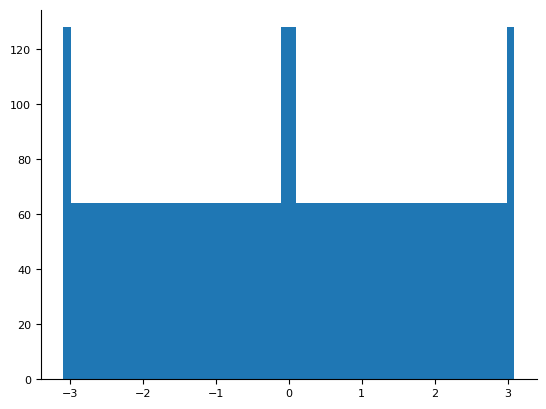

In [26]:
plt.hist(positions[..., 1].cpu().reshape(-1, 1).numpy(), bins=60)

In [50]:
def wrap_angle(angle):
    """Wrap angle to the range [-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi

torch.Size([1, 64, 2000])
torch.Size([1, 64, 2000])
torch.Size([1, 256, 2000])
torch.Size([1, 128, 2000])


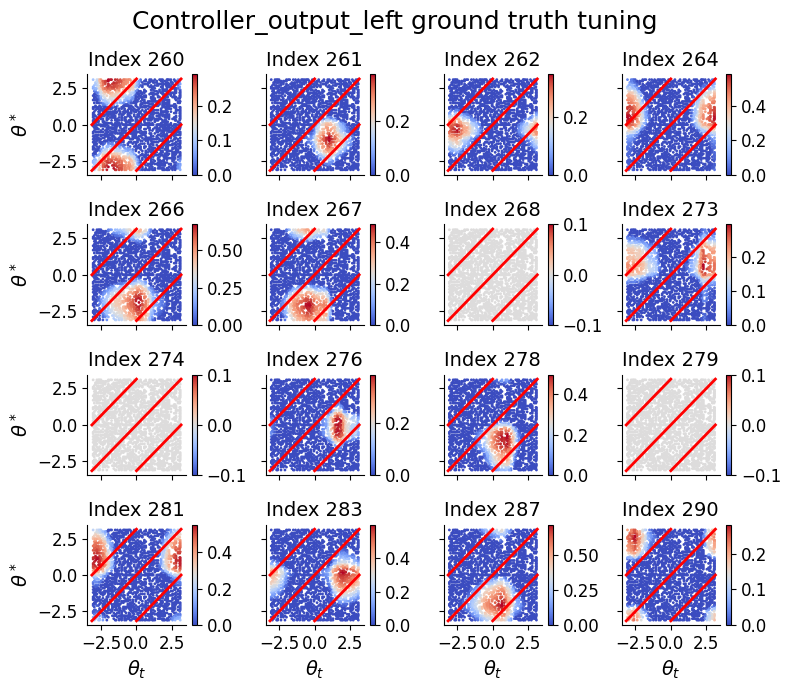

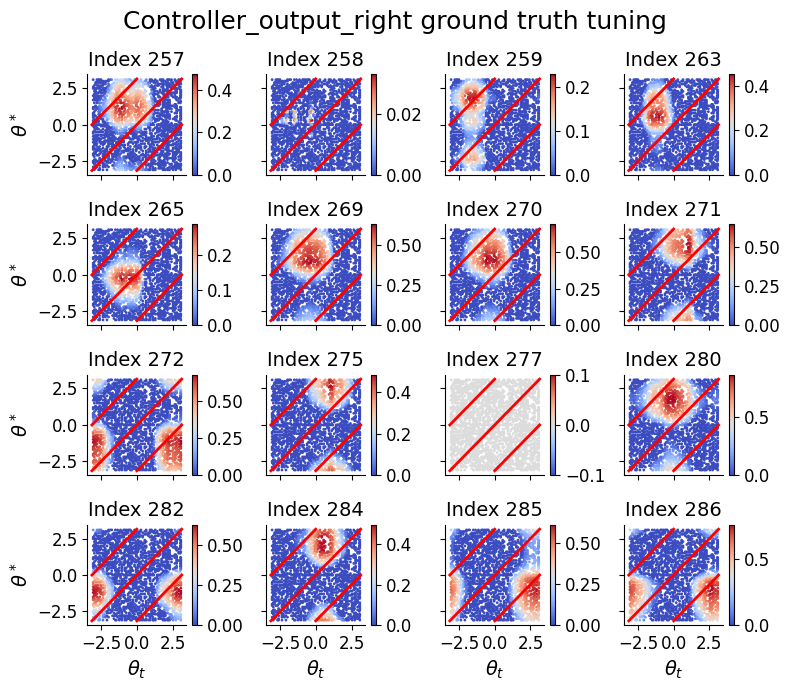

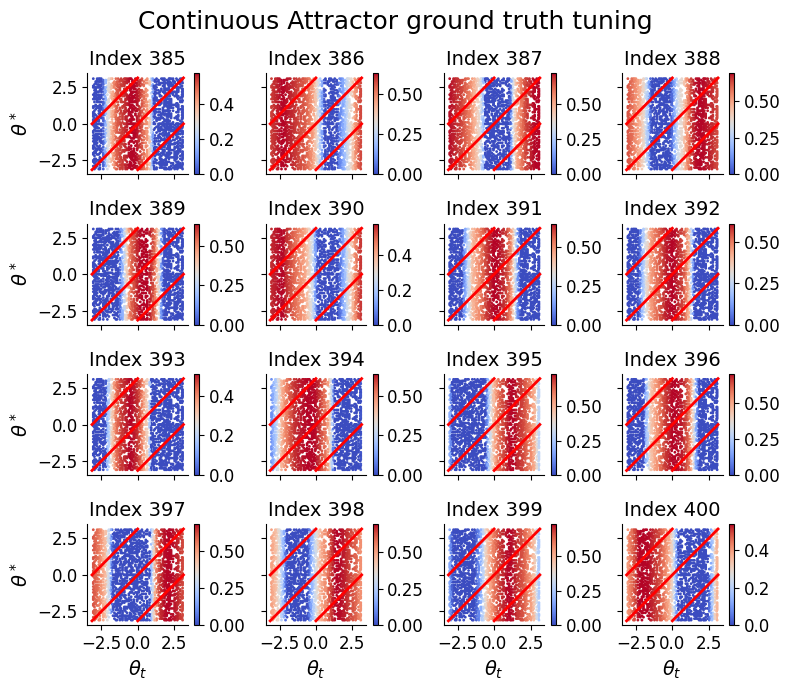

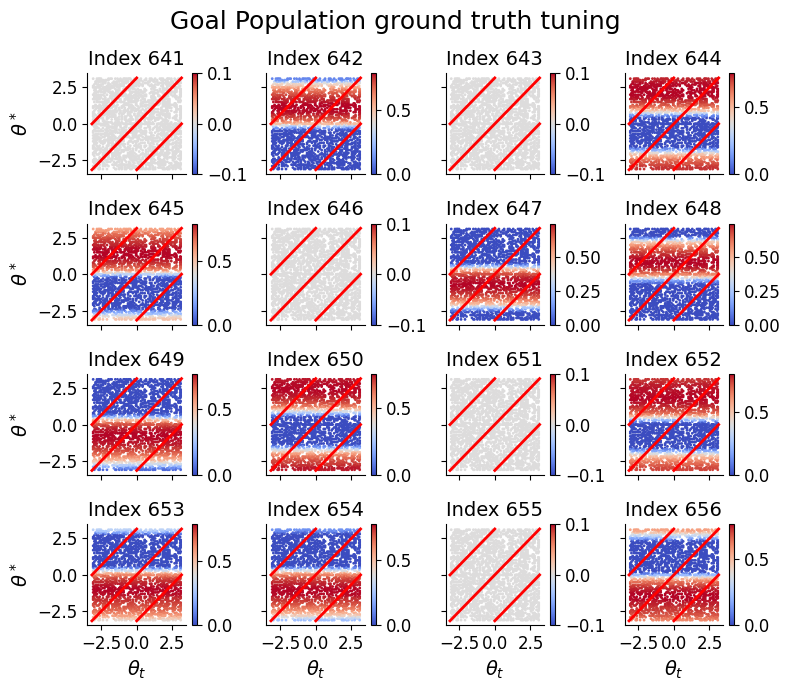

In [70]:
subsampling_index_2 = subsampling_index_2.cpu().numpy() if torch.is_tensor(subsampling_index_2) else subsampling_index_2
# for partition_id, (partition_name, (start, end)) in enumerate(partitions.items()):
    # indices = [i for i in range(neural_activations_subsampled.shape[-2]) if subsampling_index_2[i] >= start and subsampling_index_2[i] < end]
for partition_id, (partition_name, list_partition) in enumerate(partitions.items()):
    indices = [i for i in range(neural_activations_subsampled.shape[-2]) if subsampling_index_2[i] in list_partition]
    order = np.argsort(subsampling_index_2[indices])
    # subset the neural activations for the current partition
    neural_activations_subset = neural_activations_subsampled[:, indices, :]
    print(neural_activations_subset.shape)
    num_neurons = neural_activations_subset.shape[-2]
    # determine grid size for plotting
    cols = 4 if num_neurons > 5 else num_neurons
    # rows = (num_neurons + cols - 1) // cols  # calculate rows dynamically based on number of neurons
    # rows = 3 if partition_id < len(partitions) - 1 else 1
    rows = 4
    # create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, 1 + 1.5 * rows))#, constrained_layout=True)
    axes = axes.flatten()
    indices = np.array(indices)[order]
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.scatter(
            wrap_angle(positions_subsampled[:, 0].cpu().detach() ),
            wrap_angle(positions_subsampled[:, 1].cpu().detach()),
            c=neural_activations_subset[0, i, :].cpu().detach(),
            cmap="coolwarm",
            s = 1,
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$") if not goal else ax.set_ylabel(r"$\theta^*$")
        else:
            ax.set_yticklabels([])

        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$") 
        else: 
            ax.set_xticklabels([])
        
        ax.plot([-np.pi, np.pi], [-np.pi, np.pi], color="red", linestyle="-", linewidth=2)
        ax.plot([0, np.pi], [-np.pi, 0], color="red", linestyle="-", linewidth=2)
        ax.plot([-np.pi, 0], [0, np.pi], color="red", linestyle="-", linewidth=2)

        fig.colorbar(heatmap, ax=ax, orientation="vertical")


    # fig.suptitle(f"{partition_name} ground truth tuning, scaling = {scaling}{", model = " + model_name if model_name is not None else ""}", fontsize=12)
    # plt.subplots_adjust(top=0.85, bottom=0.15)

    # plt.suptitle(f"{partition_name} ground truth tuning", fontsize=12) if partition_id < len(partitions) - 1 else plt.suptitle(f"Goal Population inferred tuning", fontsize=12)
    plt.suptitle(f"{partition_name} ground truth tuning")
    fig.tight_layout()

    # plt.tight_layout()
    plt.savefig(f"{FIG_PATH}/GT_modular_{partition_name}_scaling{scaling}{model_name if model_name is not None else ""}{"goal" if goal else ""}.png", dpi=300, bbox_inches='tight')
    # break


Now we have an idea of what stuff actually looks like, we try to fit the supervised mGPLVM to data. 

Note that this plot reveals bias in the sampling procedure. This is expected because we are sampling on control trajectories; expectedly as the controller is trained, the residual motion will be biased toward 0 (or 2pi). 

In [7]:
### set some parameters for fitting ###
max_steps = 1001 # number of training iterations
n_mc = 1 # number of monte carlo samples per iteration (since the latents are a delta function, we only need 1)
print_every = 10 # how often we print training progress
d = 2 # specify the dimensionality of the space
n_z = 50 #number of inducing points; performance increases with more inducing points

In [73]:
positions_subsampled = positions_subsampled % (2 * np.pi)  # ensure positions are in the range [0, 2*pi]

In [23]:
def build_model_supervised(): 
    manif = mgp.manifolds.Torus(m, d)
    mu = positions_subsampled.unsqueeze(0)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1, sigma = 1e-5, diagonal = True, mu = mu)
    kernel = mgp.kernels.QuadExp(n, manif.distance, Y = neural_activations_subsampled, ell = np.ones(n)*1, scale = 0.7*np.ones(n)) #squared exponential kernel
    # lik = mgp.likelihoods.Gaussian(n, Y = neural_activations_subsampled, d=d)
    lik = mgp.likelihoods.Gaussian(n, )
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, n_z)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior,
    ).to(device)
    return model

def build_model_unsupervised(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True
    )
    return model


model = build_model_supervised()
# unsupervised_model = build_model_unsupervised()

TypeError: bad operand type for unary -: 'SampledDataset'

In [38]:
scale = 1
manif = mgp.manifolds.Torus(m, d)
manif.distance(
    torch.tensor([[0.0, -np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
    torch.tensor([[0.0, np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
)

tensor([[[0.]]], device='cuda:0')

In [9]:
neural_activations_subsampled = neural_activations_subsampled.detach()
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(model, neural_activations_subsampled.to(device), train_params)

fitting 224 neurons and 2000 conditions for 1001 iterations


/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/torch/utils/_device.py:78: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1718580525958/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:2184.)
  return func(*args, **kwargs)


iter   0 | elbo -2.814 | kl  0.106 | loss  2.814 | |mu| 2.938 | sig 0.000 | scale 0.700 | ell 1.000 | lik_sig 1.000 |
iter  50 | elbo -0.752 | kl  0.106 | loss  0.819 | |mu| 2.938 | sig 0.000 | scale 0.664 | ell 1.164 | lik_sig 0.749 |
iter 100 | elbo  1.003 | kl  0.107 | loss -0.910 | |mu| 2.938 | sig 0.000 | scale 0.532 | ell 1.779 | lik_sig 0.100 |
iter 150 | elbo  1.056 | kl  0.107 | loss -0.954 | |mu| 2.938 | sig 0.000 | scale 0.447 | ell 2.014 | lik_sig 0.109 |
iter 200 | elbo  1.093 | kl  0.106 | loss -0.989 | |mu| 2.938 | sig 0.000 | scale 0.417 | ell 2.048 | lik_sig 0.117 |
iter 250 | elbo  1.084 | kl  0.107 | loss -0.978 | |mu| 2.938 | sig 0.000 | scale 0.396 | ell 2.076 | lik_sig 0.120 |
iter 300 | elbo  0.981 | kl  0.106 | loss -0.875 | |mu| 2.938 | sig 0.000 | scale 0.378 | ell 2.129 | lik_sig 0.149 |
iter 350 | elbo  0.963 | kl  0.107 | loss -0.856 | |mu| 2.938 | sig 0.000 | scale 0.364 | ell 2.157 | lik_sig 0.161 |
iter 400 | elbo  1.006 | kl  0.107 | loss -0.899 | |mu| 

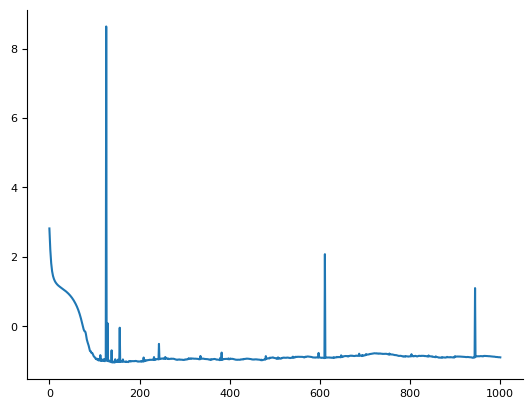

In [75]:
plt.plot(mod_train)

In [22]:
model.load_state_dict(torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2.pt"))

<All keys matched successfully>

Model trained; now visualize the tuning. 

In [22]:
position_names = [r"cos($\theta_t$)", r"sin($\theta_t$)", r"\omega", r"\dot{\omega}"]
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(-np.pi * scaling, np.pi * scaling, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
model = model.to("cpu")
fmean, fvar = model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

subsampling_index_2 = subsampling_index_2.cpu().detach().numpy()
subsets = {}
# Iterate over each partition and plot separately
for partition_id, (partition_name, (start, end)) in enumerate(partitions.items()):
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    # order = np.argsort(subsampling_index_2[indices])
    
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    subsets[partition_name] = fmean_subset
    
    # # Determine grid size for plotting

    cols = 5 if num_neurons > 5 else num_neurons
    # rows = (num_neurons + cols - 1) // cols  # calculate rows dynamically based on number of neurons
    rows = 2  #if partition_id < len(partitions) - 1 else 1
   
    # # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, 4), constrained_layout=True)
    axes = axes.flatten()
    indices = np.array(indices)[order]
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, -np.pi, np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        # ax.set_title(f"Index {subsampling_index_2[idx]}") if partition_id < len(partitions) - 1 else ax.set_title(f"{position_names[i]}")
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
   
    # Add a title for the grid
    # plt.suptitle(f"{partition_name} inferred tuning, {", model = " + model_name if model_name is not None else ""}", fontsize=12)
    plt.suptitle(f"{partition_name} inferred tuning", fontsize=12) if partition_id < len(partitions) - 1 else plt.suptitle(f"Goal Population inferred tuning", fontsize=12)
    plt.savefig(f"{FIG_PATH}/supervised_model_modular_{partition_name}_scaling{scaling}_{model_name if model_name is not None else ""}.png", dpi=300, bbox_inches='tight')
    plt.show()


AttributeError: 'str' object has no attribute 'to'

In [41]:
torch.save(model.state_dict(), f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_{model_name}.pt")
torch.save({"index 1": subsampling_index_1, "index 2": subsampling_index_2}, f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices_{model_name}.pt")

In [76]:
model.load_state_dict(torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_{model_name}.pt"))

<All keys matched successfully>

# Single dimension tuning analysis

To further replicate figures in Mussells Pires et al. 2024, we look at single dimensional tuning curves.


## Observation 1: joint tuning

- this corresponds to figure 3 in the paper
- 3d: observing that lots of cells are tuned to a current angle. 

In [11]:
controller_population_activity = neural_activations[:, partitions["Controller_output"][0]:partitions["Controller_output"][1]]
subsampled_controller_population_activity = neural_activations[subsampling_index_1][:, partitions["Controller_output"][0]:partitions["Controller_output"][1]].cpu().detach().numpy()

In [12]:
print(subsampled_controller_population_activity.shape)
print(positions_subsampled.shape)
current_angles = positions_subsampled[:, 0].cpu().numpy()
residual_angles = positions_subsampled[:, 1].cpu().numpy()
target_angles = (current_angles + residual_angles) % (2 * np.pi)

(2000, 0, 577)
torch.Size([2000, 2])


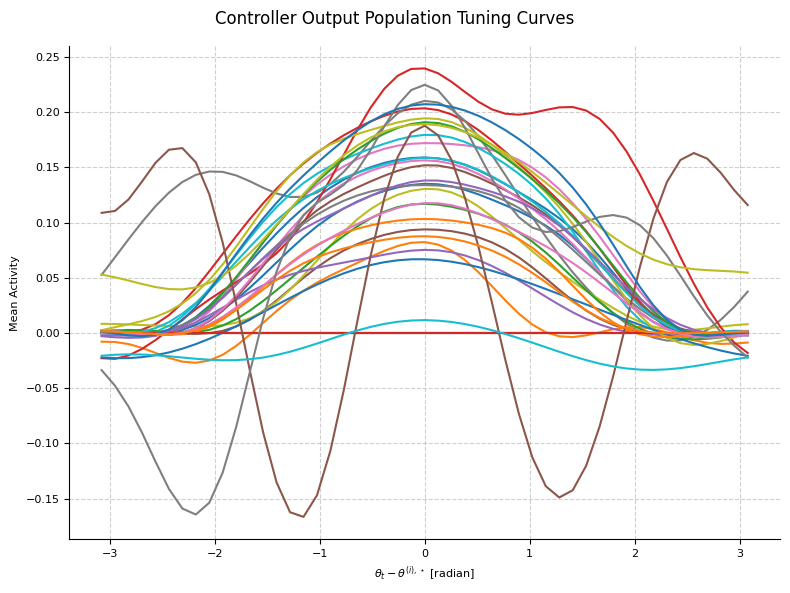

In [11]:
controller_means = subsets["Controller_output"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Output Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/type_{model_type}_controller_population_tuning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# import everything
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import Operator.Operator as o
import copy
from Network_models.CTrainer_Pred_CAN import CTrainer_Pred_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator
from Operator.miscellaneous import *
from Network_models.GRUController import GRUControllerAlltogether
from SimulateDatasets.ContrastiveGenerator import ControlGenerator_GRU
from Network_models.CTrainer_GRU import CTrainer_GRU

# set up rep net
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 1,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        # "nonlinearity" : "tanh",
        "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)

data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=-1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta

d = data_gen.generate_data(10, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()

rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1]) if dim != 1 else nn.Linear(128, dpositions.shape[1]*2),
)

mapnet = torch.load(path.replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(path.replace("model.pth", "readoutnet.pth"))

plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False

from Operator.Operator import *
from Operator.miscellaneous import *

delay = 1
plant_state_size = 32
dt_plant = 0.1
action_modality = "velocity"
feedback_noise = 0.5
output_size = 32
action_size = 1 # from plant to operator
hidden_control_dim = 128
recurrent_control_dim = hidden_control_dim if hidden_control_dim > 0 else output_size
recurrent_control = False

modularized = True

try: 
    if output_size == 32:
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly32.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal32.pth")
    else: 
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly128.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal128.pth")
    fly.delay = delay
    fly.feedback_noise = feedback_noise
except:
    print ("No model to load")

    fly = Fly(
        {
            "device": "cuda", 
            "delay": delay,
            "plant_state_size": plant_state_size,
            "dt": dt_plant,
            "action_modality": action_modality,
            "feedback_noise": feedback_noise,
            "width": 0.1, # this is the widht o the 
        }
    )
    plant = LAL(controller_dim = output_size, n_lal_neurons=plant_state_size, use_dale = True, excitation_ratio = 0.8, init_scale = 0.7, dt = dt_plant)


if modularized:
    im1 = InternalModelMLP({
        "efference1": output_size, 
        "efference2": plant_state_size,
        "sensory": fly.state_size, 
        "can": rnn.rnn.rep_units 
    }, 
    [128], 
    action_size, 
    0, "relu", "linear", zero_initialization=False).cuda()

    use_rep, use_feedback = True, True
else:
    use_rep = False
    use_feedback = False
    im1_input_size = output_size + fly.state_size * use_feedback + rnn.rnn.rep_units * use_rep
    im1 = MLP(im1_input_size, 128, action_size, 0, "relu", "linear", zero_initialization=False).cuda()
# predictor = SingleLayerLM(rnn.rnn.hidden_size, wheel.position_size, 8).cuda()
predictor = MLP(rnn.rnn.hidden_size, 128, fly.position_size, 8, "relu", "tanh", zero_initialization=False, normalize=True).cuda()
fly.readout_matrix.weight.data = torch.cat([torch.ones_like(fly.readout_matrix.weight.data[:, :plant_state_size//2]), -torch.ones_like(fly.readout_matrix.weight.data[:, plant_state_size//2:])], dim=-1)
from copy import deepcopy
def trainer_factory(cond_params):
    # 1) Copy any modules so each trainer is independent
    plant_net = deepcopy(plant)
    operator  = deepcopy(fly)
    IM1_net   = deepcopy(im1)
    # predictor/readout
    predictor_copy = deepcopy(readoutnet)
    readout_net    = readoutnet

    # 2) Build the model_params, merging in cond_params
    hidden_dim = cond_params["hidden_control_dim"]
    model_params = {
        "rep_net": rnn,
        "plant": plant_net,
        "operator": operator,
        "IM1": IM1_net,
        "predictor": predictor_copy,
        "readoutnet": readout_net,
        "output_size":        cond_params["output_size"],
        "rep_units_only":     True,
        "recurrent_control":  cond_params["recurrent_control"],
        "activation":         "ReLU",
        "hidden_control_dim": hidden_dim,
        "recurrent_control_dim": hidden_dim if hidden_dim != 0 else cond_params["output_size"],
        "device":             "cuda",
        "use_rep":            use_rep,
        "use_feedback":       use_feedback,
    }

    model_specs = {
        "model_name":   "PredControlNetCAN_2",
        "model_path":   "Network_models.PIDController",
        "model_params": model_params,
    }

    optimizer_specs = {
        "compartmental_optimization": True,
        "optimizer_name":             "Adam",
        "optimizer_params":           {"lr": 0.003},
    }

    # 3) Put together the trainer config
    trainer_config = {
        "model_specs":              model_specs,
        "optimizer_specs":          optimizer_specs,
        "control_period":           20,
        "random_initial_condition": True,
        "additional_loss":          ["final_distance", "control_norm"],
        "save_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/", 
        "check_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/",
        "log_path":           LOG_PATH + f"/Pred_Controller/Temp/",
        # (you can add save_path/check_path/log_path here if needed)
    }

    # 4) Instantiate and return
    return CTrainer_Pred_CAN(trainer_config)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
input_connected: True
Using custom activation BiologicalReLU
1
no scheduler
Model loaded via train
0.1


In [3]:
path_dicts = {
    1: {
        "it": 0, 
        "control_norm_weight": 0.3
    },
    2: {
        "it": 0,
        "control_norm_weight": 1.5
    },
    3: {
        "it": 2,
        "control_norm_weight": 3.1
    }
}

conditions = {
    "full": {
        "recurrent_control": True,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_hidden": {
        "recurrent_control": True,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
    "no_hidden_no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
}

it = path_dicts[model_type]["it"]
condition = "no_hidden_no_recurrence"
action_weight_, loss_traj_weight_, convergence_loss_weight_, control_norm_weight_ = 0.3, 0.3, 0.3, path_dicts[model_type]["control_norm_weight"]

weight_dict = {
    "action_weight": action_weight_,
    "loss_traj_weight": loss_traj_weight_,
    "convergence_loss_weight": convergence_loss_weight_,
    "control_norm_weight": control_norm_weight_
}
action_weight, loss_traj_weight, convergence_loss_weight, control_norm_weight = weight_dict.values()

trainer = trainer_factory(conditions[condition])
output_size = conditions[condition]["output_size"]
hidden_control_dim = conditions[condition]["hidden_control_dim"]
recurrent_control = conditions[condition]["recurrent_control"]
path = MODEL_SAVE_PATH + f"/LAL/modularized_cp_{"single_sheet" if hidden_control_dim == 0 else "hidden" + str(hidden_control_dim)}_{output_size}_{loss_traj_weight}_{action_weight}_{convergence_loss_weight}_{control_norm_weight}_iteration{it}{"no_recurrence" if not recurrent_control else ""}.pth"
trainer.load_checkpoint(path)
# state_dict = torch.load(MODEL_SAVE_PATH + "/LAL/modularized_cp_5") if model_name == "LAL_weight_decay" else torch.load(MODEL_SAVE_PATH + "/LAL/modularized_cp_single_sheet32") if model_name == "LAL_weight_decay_single_layer_32" else torch.load(MODEL_SAVE_PATH + "/LAL/modularized_cp_single_sheet128")
# state_dict = torch.load(path_dicts[model_type])

NameError: name 'model_type' is not defined

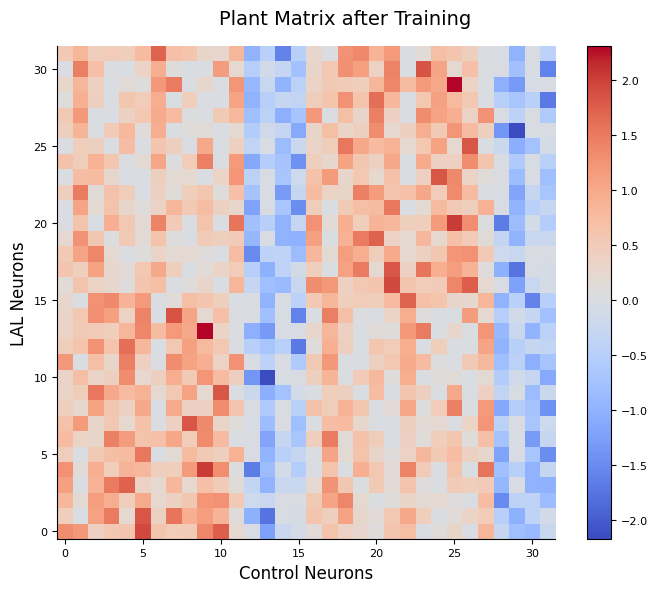

In [41]:
import torch.nn.functional as F

plt.figure(figsize=(7, 6))
# W_pos = F.softplus(model_state_dict["plant.W_param"]) * model_state_dict["plant.dale_signs"]
W_pos = trainer.model.plant.apply_dale_constraint(trainer.model.plant.W_param.data).cpu().detach()
plt.imshow(W_pos.cpu().numpy(), cmap="coolwarm", aspect="auto", origin = "lower")
plt.colorbar()
plt.suptitle("Plant Matrix after Training", fontsize=14)
plt.xlabel("Control Neurons", fontsize=12)
plt.ylabel("LAL Neurons", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_PATH + f"/plant_matrix_after_training{model_type}.png", dpi=300)


In [32]:
model_state_dict["operator.readout_matrix.weight"] @ W_pos

tensor([[-1.8613, -2.0204,  1.3704, -1.3575,  0.8629,  0.5509, -1.3075, -1.1453,
          1.0762,  0.8723,  1.1240, -1.5815, -1.9011,  1.3862,  2.1835, -1.0829,
          0.5353,  1.3200, -0.0069,  0.9391,  0.2178,  1.5820, -1.8505,  1.1505,
          1.6455, -1.4497,  0.5051,  0.5986, -1.4646,  1.4180,  1.1547, -1.0507]],
       device='cuda:0', dtype=torch.float32)

In [33]:
controller_signs

array([-1., -1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1., -1.,
        1.,  1., -1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1.,
        1.,  1., -1.,  1.,  1., -1.], dtype=float32)

26 0
3 1
7 3
2 6
15
1.9234240736264034
18 7
13 11
29 12
12 15
8 18
21 22
1 25
4 28
11 31


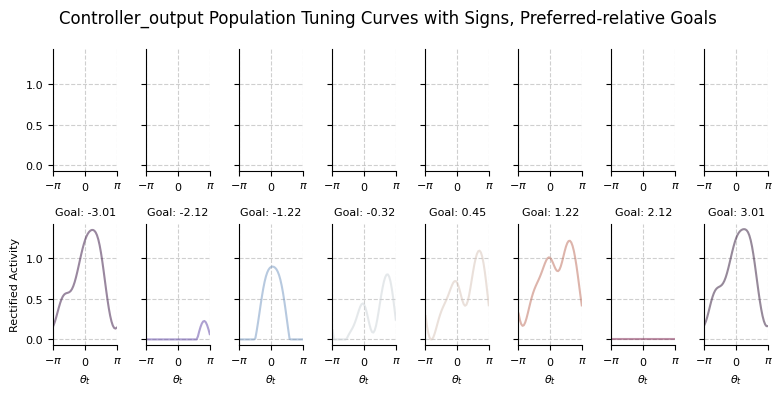

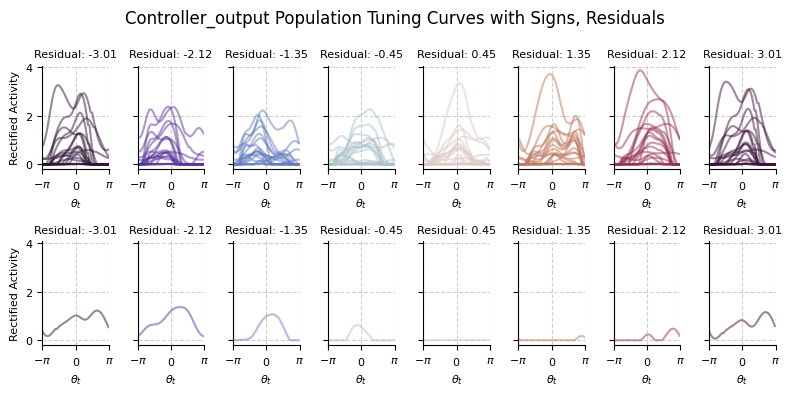

In [94]:
# reindex = subsampling_index_2[128:128+32] - 257
# subsampled_index_controller_out = torch.zeros(32)
# for i in range(32):
#     subsampled_index_controller_out[i] = torch.where(reindex == i)[0][0]

# subsampled_index_controller_out
squared = False
scaled = True
# controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
# controller_signs = controller_signs.cpu().numpy()
# controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = torch.sign(model_state_dict["operator.readout_matrix.weight"] @ W_pos)[0]
controller_signs = controller_signs.cpu().numpy()
controller_mags = torch.abs(model_state_dict["operator.readout_matrix.weight"] @ W_pos).cpu().numpy()[0]
reindex = subsampling_index_2[64:64+32]
# utils.plot_joint_tuning("Controller_output", subsets, theta1, theta2, np.array(subsampled_index_controller_out.cpu().numpy(), dtype = np.int16), controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)
utils.plot_joint_tuning("Controller_output", subsets, theta1, theta2, reindex - 257, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

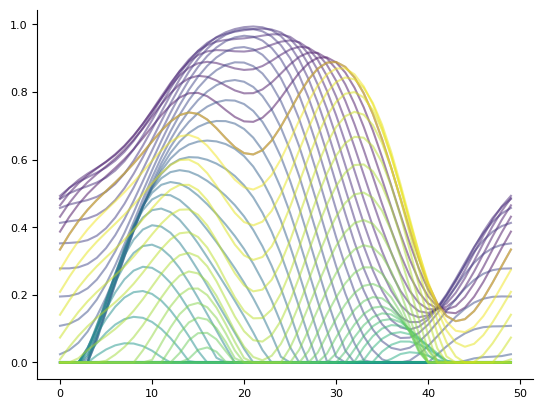

In [90]:
colors = plt.get_cmap("viridis")(np.linspace(0, 1, 50))
for i in range(50):
    plt.plot(subsets["Controller_output"][:, i, 2].clip(min =0), color = colors[i], alpha = 0.5)

In [80]:
subsets["Controller_output"][:, :, 2].shape

(50, 50)

In [48]:
a = np.array([[1, 2, 3], [2, 3, 4]])
b = np.roll(a, -1, axis = 0)
print(a)
print(b)

[[1 2 3]
 [2 3 4]]
[[2 3 4]
 [1 2 3]]


In [21]:
reindex

tensor([277, 282, 263, 258, 285, 280, 262, 260, 275, 270, 281, 288, 272, 268,
        265, 286, 274, 259, 264, 278, 267, 279, 276, 287, 271, 273, 257, 284,
        283, 269, 261, 266])

In [55]:
positions_subsampled[..., 0] = ((positions_subsampled[..., 0] + np.pi) % (2 * np.pi) - np.pi)

## what we found was that the output control cells are organized by residual rotations. 

What about the hidden cells?

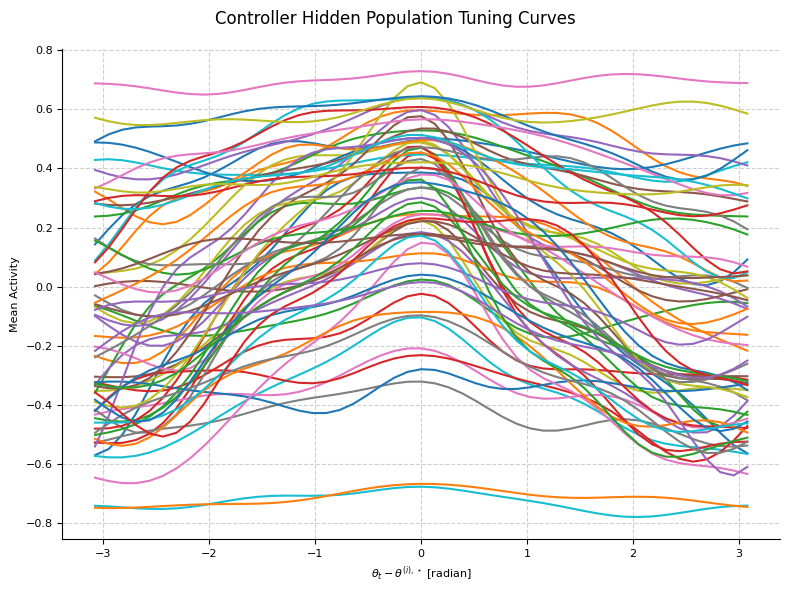

In [18]:
controller_means = subsets["Controller_hidden"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Hidden Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves_hidden.png", dpi=300, bbox_inches="tight")
plt.show()

[-1. -1.  1. -1.  1.  1. -1. -1.  1.  1.  1. -1. -1.  1.  1. -1.  1.  1.
 -1.  1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.]


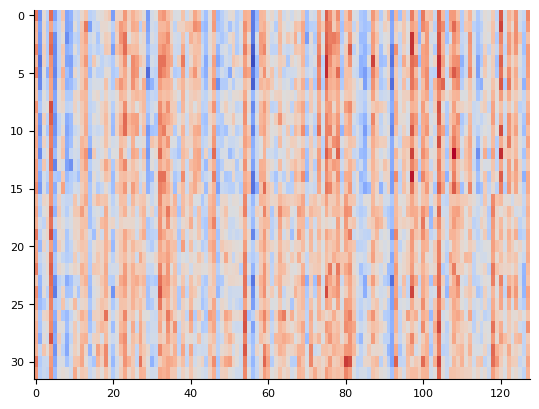

In [103]:
W_control = W_pos @ model_state_dict["out.weight"] 
plt.imshow(W_control.cpu().numpy(), cmap="coolwarm", aspect="auto")
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_signs = controller_signs.cpu().numpy()
print(controller_signs)

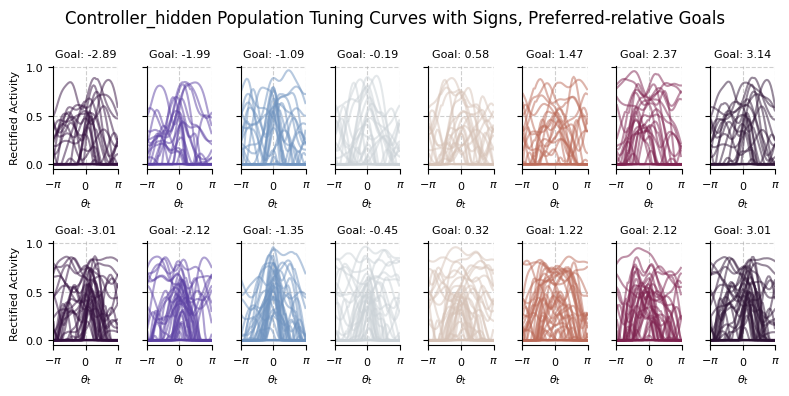

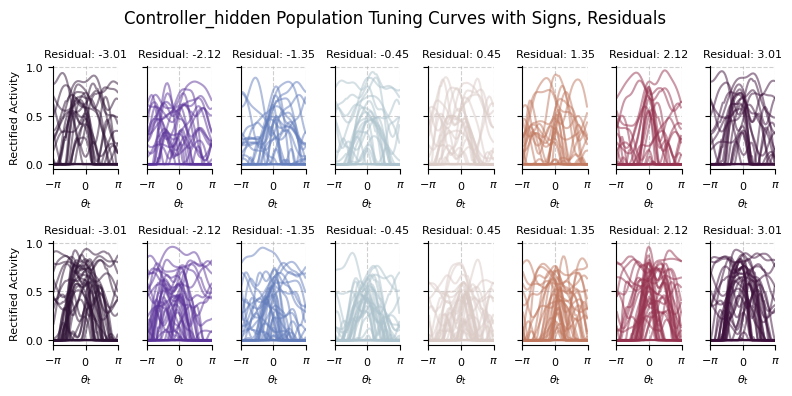

In [108]:
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()
reindex = subsampling_index_2[64:128] 
utils.plot_joint_tuning("Controller_hidden", subsets, theta1, theta2, reindex - 128, controller_signs, controller_mags,  
                        squared = False, scaled = False, save = True, show = True)

Let's check out internal models now!

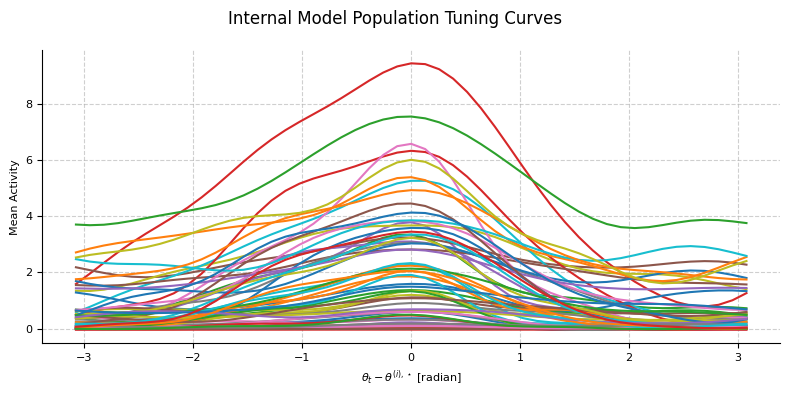

In [138]:
controller_means = subsets["Internal Model"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 4))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Internal Model Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves_im.png", dpi=300, bbox_inches="tight")
plt.show()

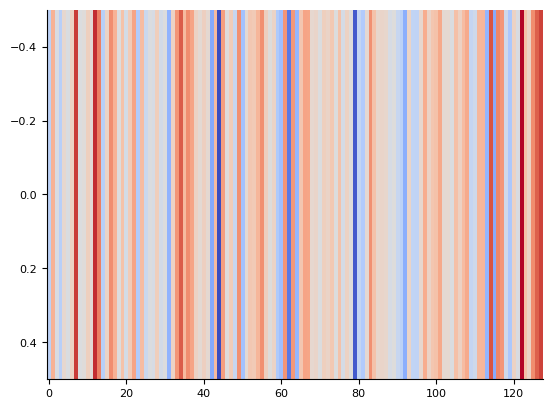

In [23]:
plt.imshow(model_state_dict["im1.W_output.weight"].cpu().detach().numpy(), cmap = "coolwarm", aspect = "auto")

In [164]:
subsets.keys()

dict_keys(['Internal Model', 'Controller_hidden', 'Controller_output', 'Continuous Attractor'])

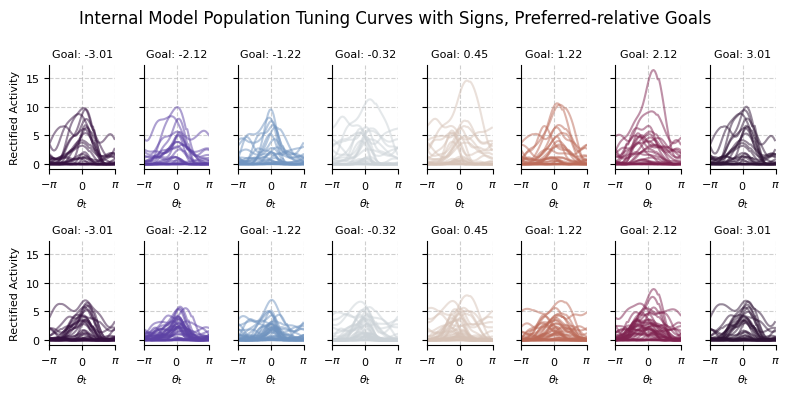

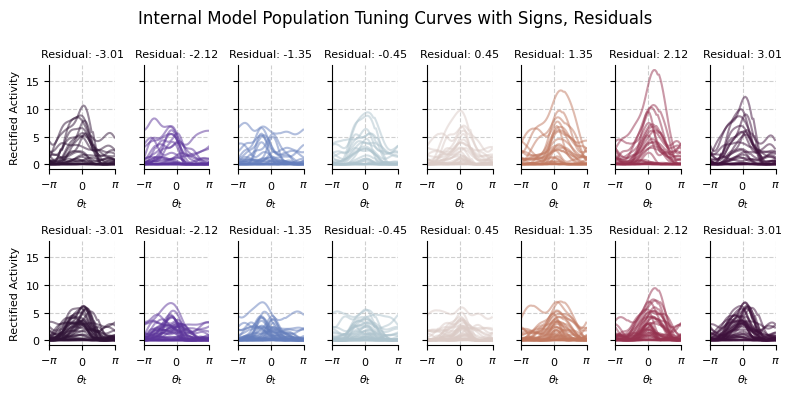

In [110]:
squared = False
scaled = False
controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
reindex = subsampling_index_2[0:64]
utils.plot_joint_tuning("Internal Model", subsets, theta1, theta2, reindex, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

# Raw data

we use the same procedure to plot for the raw data now. Respectively for each cell type, we can check the tuning curve from binned averaged mGPLVM fits as well as raw data

## First do controller output

In [60]:
neural_activations.shape

torch.Size([163840, 545])

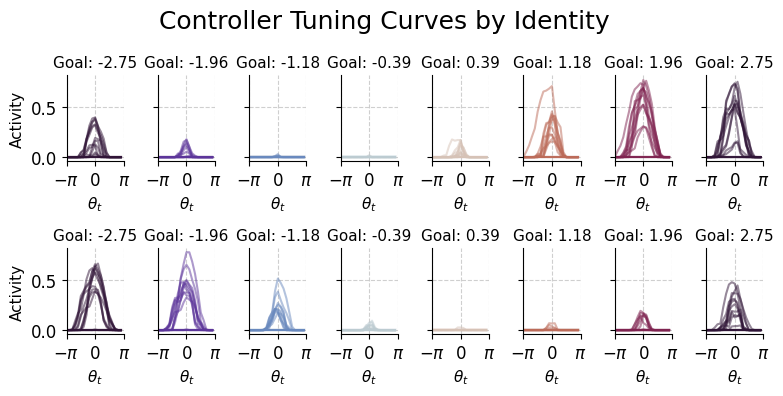

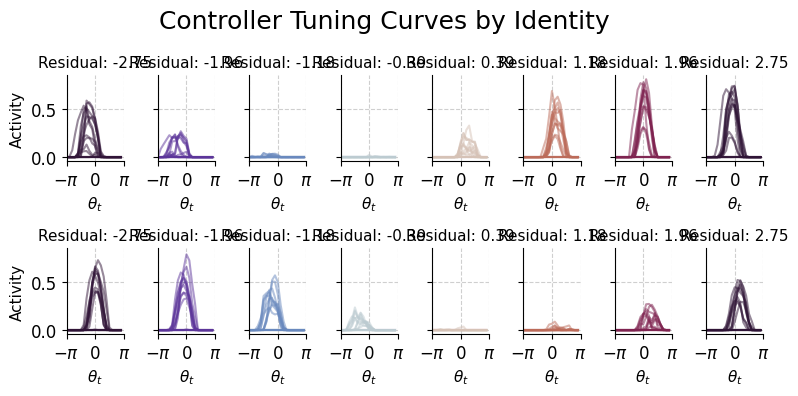

In [404]:
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 11
population = "Controller_output"
partitions = {
    "Controller_output": (161, 193),
}
squared = False
scaled = False
# controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
# controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
# controller_signs = controller_signs.cpu().numpy()

# controller_signs = torch.sign(model_state_dict["operator.readout_matrix.weight"] @ W_pos)[0]
# controller_signs = controller_signs.cpu().numpy()
# controller_mags = torch.abs(model_state_dict["operator.readout_matrix.weight"] @ W_pos).cpu().numpy()[0]
controller_signs = torch.sign(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu())[0].cpu().numpy()
controller_mags = torch.abs(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu()).cpu().numpy()[0]
neural_activations = neural_activations.reshape(-1, neural_activations.shape[-1])
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions[population][0]:partitions[population][1]]
fig1, fig2 = utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    rectify = False, 
    save = False, show = False, n_bins = 8,n_theta_bins = 20, population =population,
)
# fig1.savefig(FIG_PATH + f"/LAL_controller_output_joint_tuning_{model_type}_.png", dpi=300, bbox_inches='tight')
# fig1.savefig(FIG_PATH + f"/LAL_controller_output_joint_tuning_{model_type}.png", dpi=300, bbox_inches='tight')
# fig2.savefig(FIG_PATH + f"/LAL_controller_output_joint_tuning_{model_type}_residual.png", dpi=300, bbox_inches='tight')
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [120]:
controller_weights = trainer.model.W_xh.weight.data.cpu().detach()
controller_weights.shape

torch.Size([32, 384])

In [311]:
def plot_lal_activity_binned(positions_subsampled, subsampled_controller_hidden, W_pos, n_bins=16):
    """
    Plot LAL population activities (left, right, and difference) against goal angle,
    with both scatter and binned mean ± SEM overlay.

    Args:
        positions_subsampled: torch.Tensor (B, 2), with column 1 = goal angle
        subsampled_controller_hidden: torch.Tensor (B, D), hidden activity
        W_pos: torch.Tensor (L, D), LAL readout weights
        n_bins: int, number of angular bins
    """
    lal_activity = F.relu(W_pos.cpu() @ subsampled_controller_hidden.T.cpu())  # (L, B)
    left_lal = lal_activity[:16].T.detach().numpy().sum(axis=1)
    right_lal = lal_activity[16:].T.detach().numpy().sum(axis=1)
    diff_lal = right_lal - left_lal

    goal_angles = positions_subsampled[:, 1].cpu().detach().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(8, 3), sharex=True)
    titles = ['Right LAL Activity', 'Left LAL Activity', 'Right - Left LAL Activity']
    datas = [right_lal, left_lal, diff_lal]
    cmap = plt.cm.twilight_shifted

    edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2

    for i, (ax, data, title) in enumerate(zip(axs, datas, titles)):
        # Scatter
        ax.scatter(goal_angles, data, s=10, alpha=0.4, label='Single Trials', color=cmap(0.65))

        # Binned stats
        means = np.zeros(n_bins)
        sems = np.zeros(n_bins)
        for j in range(n_bins):
            mask = (goal_angles >= edges[j]) & (goal_angles < edges[j+1])
            vals = data[mask]
            if len(vals):
                means[j] = vals.mean()
                sems[j] = vals.std(ddof=1) / np.sqrt(len(vals))
            else:
                means[j] = np.nan
                sems[j] = np.nan

        ax.plot(centers, means, '-o', color='black', label='Mean ± SEM')
        ax.fill_between(centers, means - sems, means + sems, color='black', alpha=0.2)

        ax.set_title(title)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$0$", r"$\pi$"])
        ax.grid(True, linestyle='--', alpha=0.6)

    axs[1].set_xlabel("Heading Relative to Goal")
    # axs[-1].legend(loc='upper right', fontsize=12, frameon=False)

    fig.supylabel("Summed LAL Activity")
    fig.suptitle("LAL Population Activity vs Goal Angle")
    plt.tight_layout()
    return fig


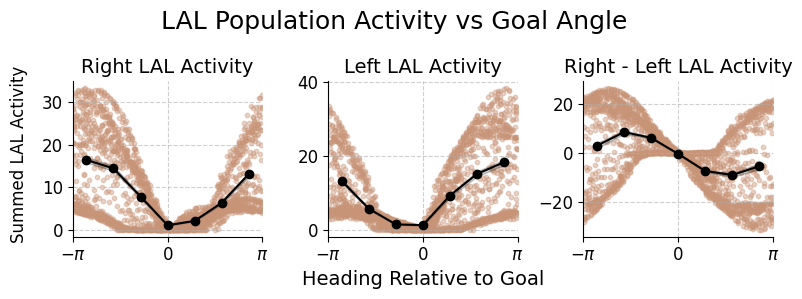

In [405]:
fig = plot_lal_activity_binned(positions_subsampled, subsampled_controller_hidden, W_pos, n_bins = 7)
fig.savefig(FIG_PATH + f"/LAL_lal_activity_binned_{model_type}.png", dpi=300, bbox_inches='tight')

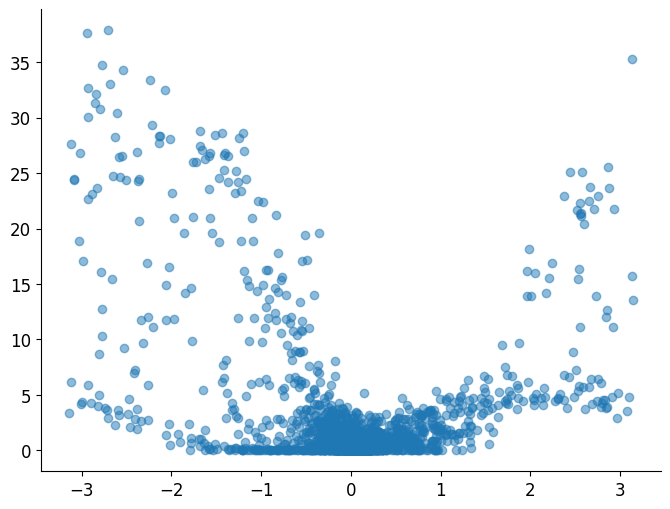

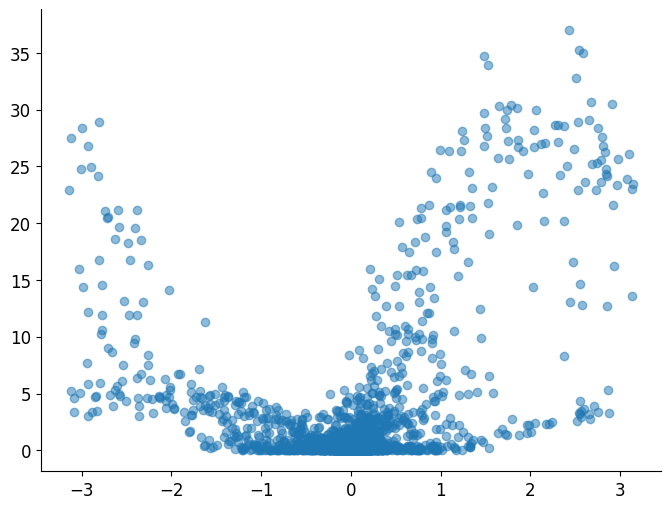

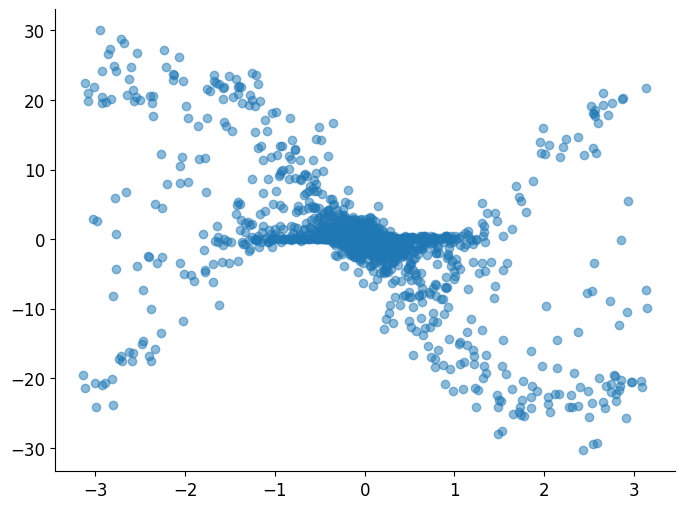

In [277]:
import torch.nn.functional as F
lal_activity = F.relu(W_pos.cpu() @ subsampled_controller_hidden.T.cpu())
left_lal_activity = lal_activity[:16, :].T.detach().sum(axis=1).unsqueeze(1)
right_lal_activity = lal_activity[16:, :].T.detach().sum(axis=1).unsqueeze(1)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i] - left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)


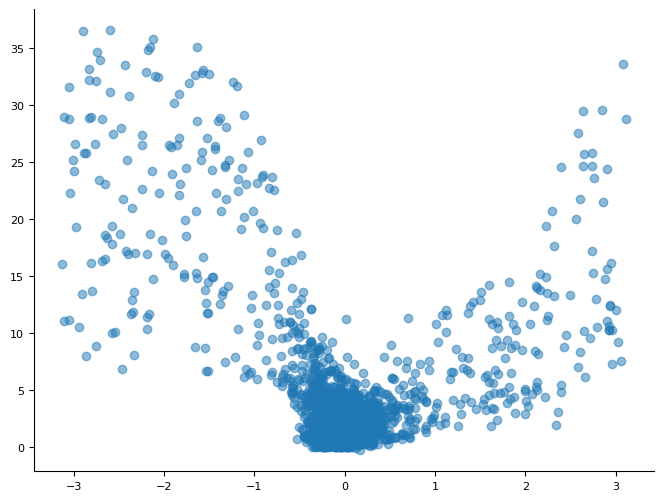

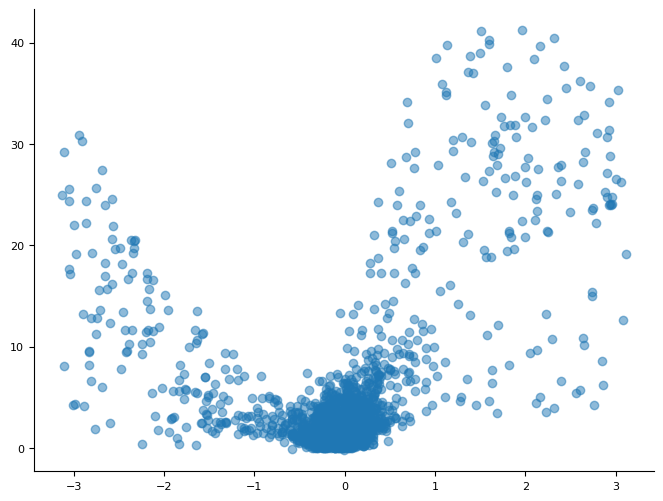

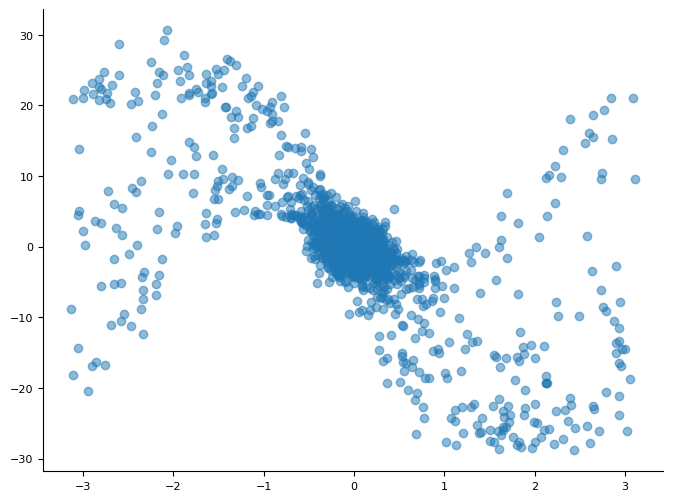

In [122]:
lal_activity = W_pos.cpu() @ subsampled_controller_hidden.T.cpu()
left_lal_activity = lal_activity[:16, :].T.detach().sum(axis=1).unsqueeze(1)
right_lal_activity = lal_activity[16:, :].T.detach().sum(axis=1).unsqueeze(1)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i] - left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)


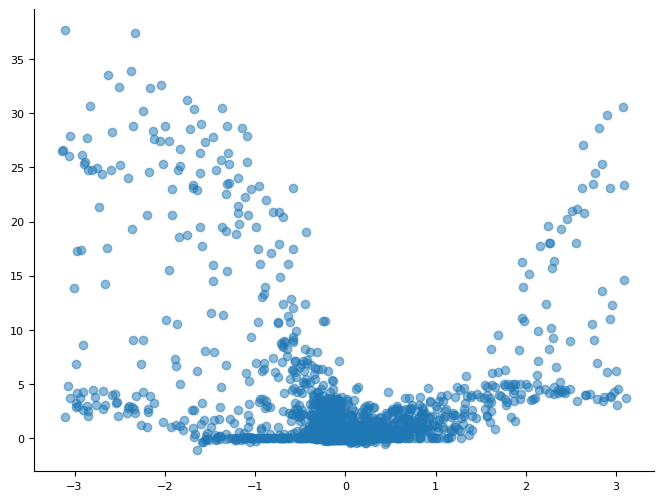

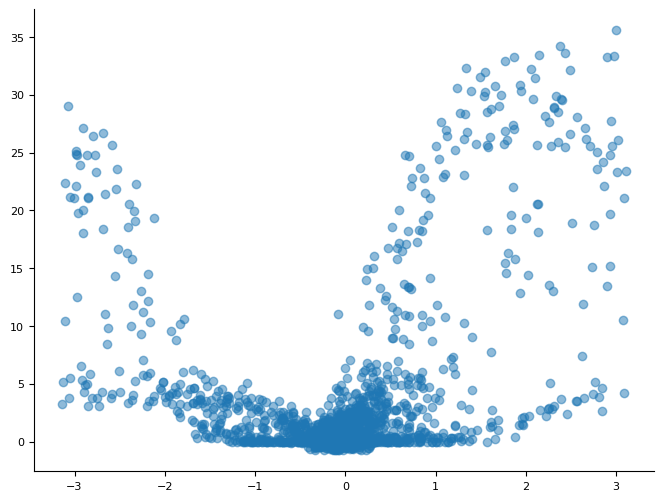

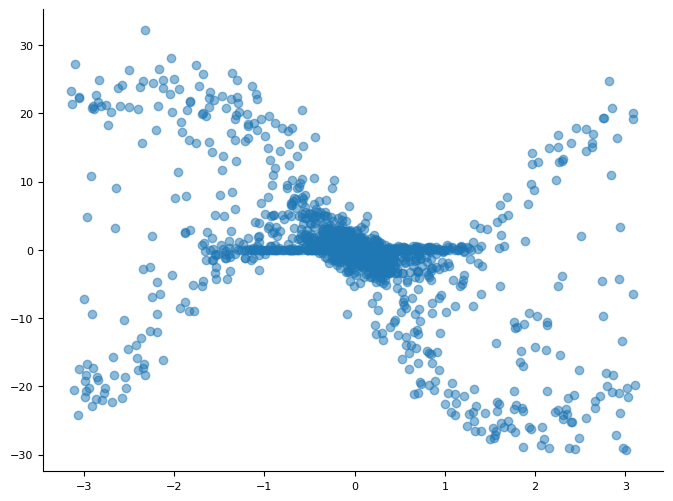

In [104]:
lal_activity = W_pos.cpu() @ subsampled_controller_hidden.T.cpu()
left_lal_activity = lal_activity[:16, :].T.detach().sum(axis=1).unsqueeze(1)
right_lal_activity = lal_activity[16:, :].T.detach().sum(axis=1).unsqueeze(1)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)
plt.figure(figsize=(8, 6))
for i in range(left_lal_activity.shape[1]):
    plt.scatter(positions_subsampled[:, 1].cpu().detach().numpy(), right_lal_activity[:, i] - left_lal_activity[:, i], label=f"LAL {i+1}", alpha=0.5)


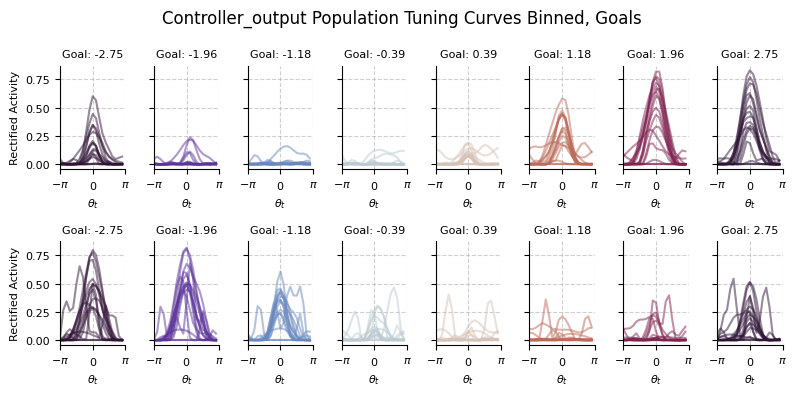

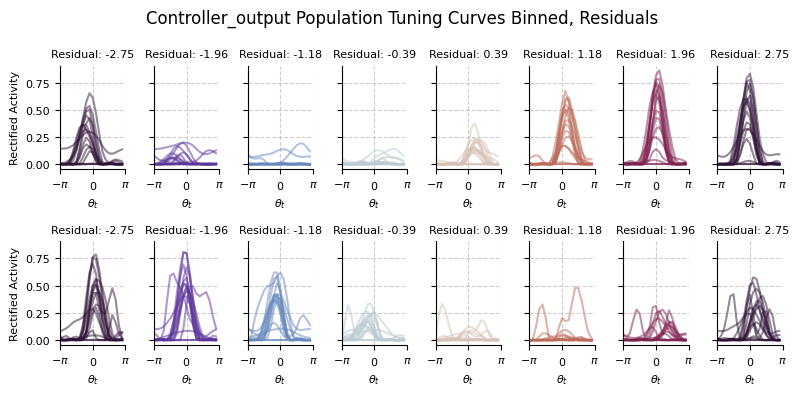

In [21]:
#check agreement with mgplvm activations
squared = False
scaled = False
# controller_signs = torch.sign(model_state_dict["operator.readout_matrix.weight"] @ W_pos)[0]
# controller_signs = torch.sign(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu())[0].cpu().numpy()
reindex = np.array(subsampling_index_2[32:64].cpu(), dtype = np.int16) - 161 if isinstance(subsampling_index_2, torch.Tensor) else np.array(subsampling_index_2[32:64], dtype = np.int16) - 161
controller_signs = torch.sign(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu())[0].cpu().numpy()
controller_mags = torch.abs(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu()).cpu().numpy()[0][reindex]
fig1, fig2 =utils.plot_joint_tuning_binned(
    activations=subsets["Controller_output"].reshape(-1, subsets["Controller_output"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index=reindex,
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = False, n_bins = 8,n_theta_bins = 20, population = "Controller_output",
)
fig1.savefig(FIG_PATH + f"/LAL_controller_output_joint_tuning_mgplvm_{model_type}.png", dpi=300, bbox_inches='tight')
fig2.savefig(FIG_PATH + f"/LAL_controller_output_joint_tuning_mgplvm_{model_type}_residual.png", dpi=300, bbox_inches='tight')

In [45]:
np.array(subsampling_index_2[64:96].cpu(), dtype = np.int16)k

array([305, 253, 394, 211, 412, 367, 403, 257, 329, 337, 291, 373, 239,
       236, 304, 338, 404, 383, 428, 209, 360, 298, 395, 358, 444, 415,
       300, 221, 407, 282, 344, 321], dtype=int16)

## Then same thing for the hidden controller units

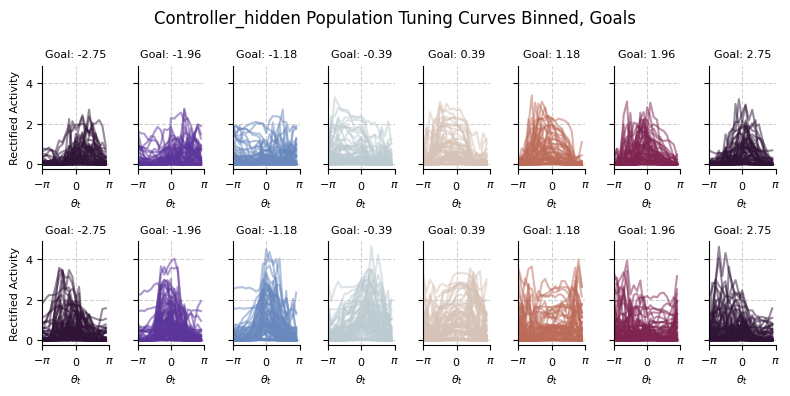

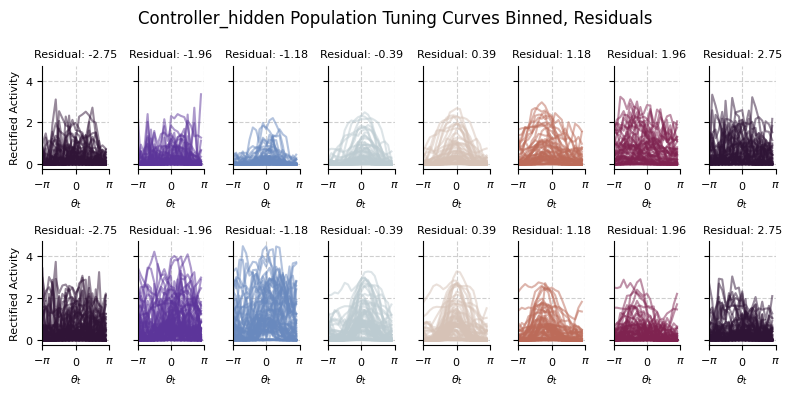

In [104]:
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions["Controller_hidden"][0]:partitions["Controller_hidden"][1]]
squared = False
scaled = True
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 20, population = "Controller_hidden",
)

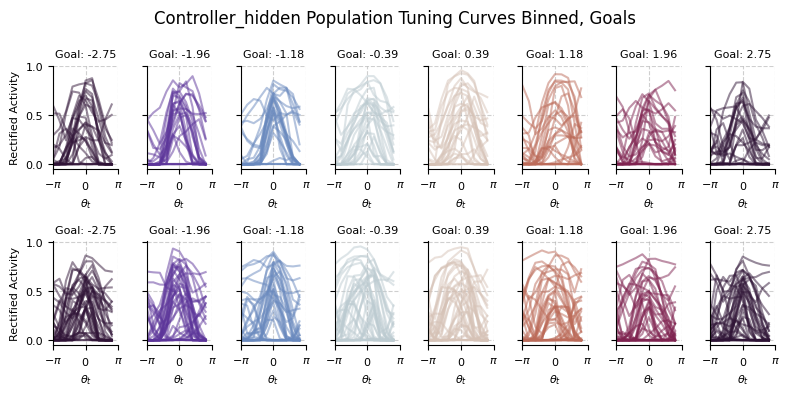

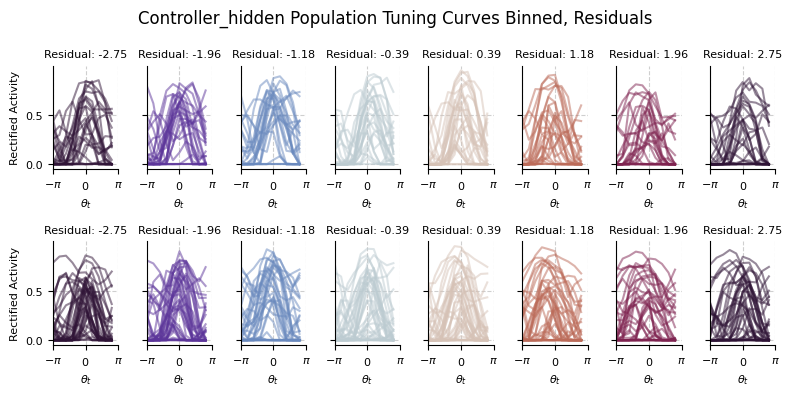

In [130]:
squared = False
scaled = False
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

reindex = np.array(subsampling_index_2[64:128], dtype = np.int16) - 128
utils.plot_joint_tuning_binned(
    activations=subsets["Controller_hidden"].reshape(-1, subsets["Controller_hidden"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index = reindex, 
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population = "Controller_hidden",
)

Finally internal model

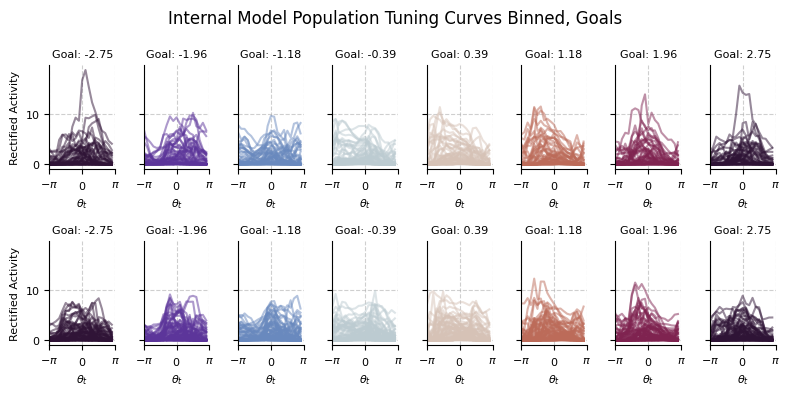

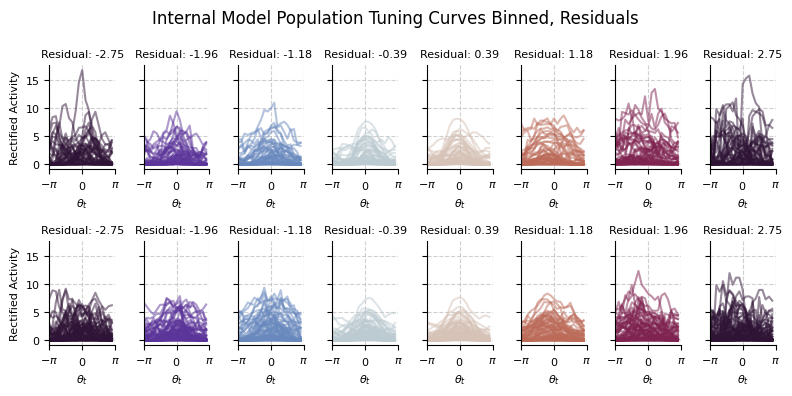

In [136]:
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions["Internal Model"][0]:partitions["Internal Model"][1]]
squared = False
scaled = False

controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 20, population = "Internal Model",
)

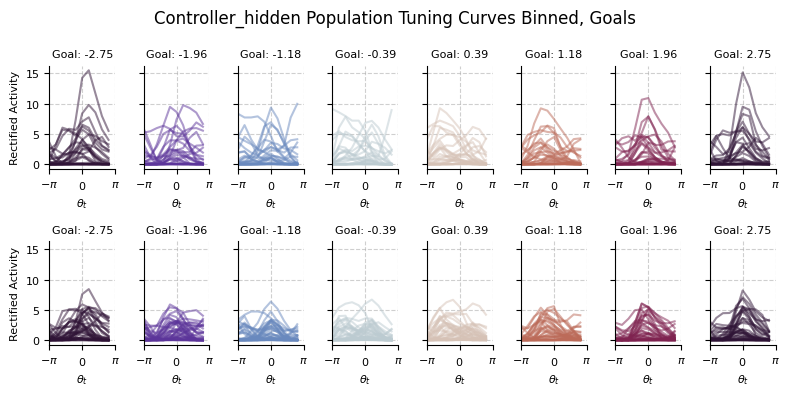

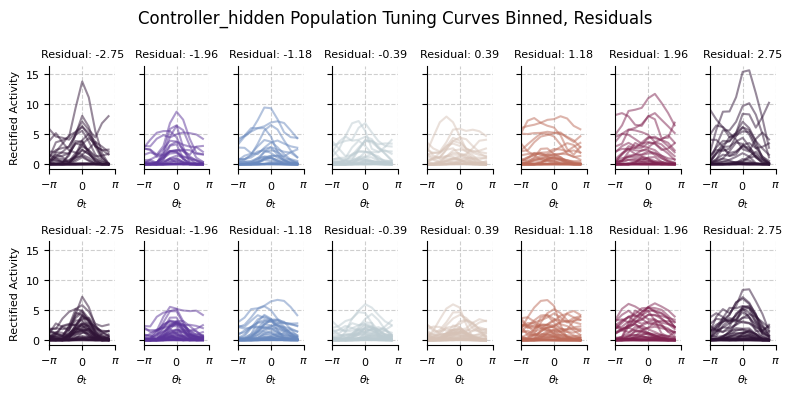

In [137]:
squared = False
scaled = False

controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()

reindex = np.array(subsampling_index_2[:64], dtype = np.int16) 
utils.plot_joint_tuning_binned(
    activations=subsets["Internal Model"].reshape(-1, subsets["Internal Model"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index = reindex, 
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population = "Controller_hidden",
)